In [242]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import stats
from sklearn.feature_selection import VarianceThreshold
from IPython.display import display

warnings.filterwarnings('ignore')
plt.style.use('ggplot')
sns.set_palette('viridis')
%matplotlib inline

SEED = 42
np.random.seed(SEED)

## Загрузка данных

Файлы `train.csv`, `test.csv` должны находиться в папке `data/`.


In [243]:
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')

# Переименовываем таргеты для удобства (в исходном train они с единицами измерения)
train.rename(columns={'IC50, mM': 'IC50', 'CC50, mM': 'CC50'}, inplace=True)

train.head()

,index,IC50,CC50,SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,102.414420,95.757483,0.935000,5.466584,5.466584,0.719259,0.719259,0.681165,18.307692,...,1,0,0,0,0,0,0,0,0,0
1,1,0.044333,8.401080,189.500000,11.492712,11.492712,0.012350,-3.798024,0.769122,27.652174,...,0,1,0,0,0,0,0,0,0,0
2,2,4.437964,50.085589,11.285714,5.366084,5.366084,0.522930,0.522930,0.612606,24.608696,...,0,0,0,0,0,0,0,0,0,0
3,3,6.827881,682.788051,100.000000,13.317130,13.317130,0.020658,-4.829339,0.345823,12.400000,...,0,0,1,0,0,0,0,0,0,0
4,4,2.003253,70.001455,34.943894,6.320833,6.320833,0.300347,0.300347,0.562066,60.272727,...,0,0,0,0,0,0,0,0,0,0


## Целевые переменные

In [244]:
TARGETS = ['IC50', 'CC50', 'SI']

## Первичный обзор

Общая информация о данных и статистики.

In [245]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 751 entries, 0 to 750
Columns: 214 entries, index to fr_urea
dtypes: float64(107), int64(107)
memory usage: 1.2 MB


In [246]:
train.describe().round(3)

,index,IC50,CC50,SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
count,751.000,751.000,751.000,751.000,751.000,751.000,751.000,751.000,751.000,751.000,...,751.000,751.000,751.000,751.000,751.000,751.000,751.0,751.000,751.000,751.000
mean,375.000,204.544,577.426,89.153,10.860,10.860,0.180,-0.972,0.578,29.588,...,0.056,0.013,0.011,0.001,0.001,0.055,0.0,0.069,0.182,0.007
std,216.939,370.368,641.515,788.882,3.347,3.347,0.169,1.594,0.214,12.713,...,0.272,0.115,0.103,0.036,0.036,0.227,0.0,0.254,1.227,0.081
min,0.000,0.004,0.701,0.011,2.322,2.322,0.000,-6.993,0.060,9.545,...,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,0.000
25%,187.500,13.222,99.999,1.500,8.921,8.921,0.048,-1.334,0.443,18.306,...,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,0.000
50%,375.000,44.069,376.581,4.000,12.198,12.198,0.121,-0.419,0.636,29.281,...,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,0.000
75%,562.500,206.787,877.509,17.372,13.214,13.214,0.291,0.072,0.742,38.875,...,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,0.000
max,750.000,4095.189,4538.976,15620.600,15.933,15.933,1.375,1.375,0.947,60.273,...,2.000,1.000,1.000,1.000,1.000,1.000,0.0,1.000,20.000,1.000


## Вспомогательные функции

In [ ]:
def display_columns_info(df, columns=None):
    """Выводит подробную статистику по колонкам: тип, пропуски, уникальные значения, мин/макс/среднее/ско"""

    if columns is None:
        columns = df.columns.tolist()
    
    info_list = []
    
    for col in columns:
        info_list.append({
            'column': col,
            'dtype': df[col].dtype,
            'missing': df[col].isnull().sum(),
            'missing_pct': df[col].isnull().sum() / len(df) * 100,
            'unique': df[col].nunique(),
            'min': df[col].min() if df[col].dtype in ['float64', 'int64'] else None,
            'max': df[col].max() if df[col].dtype in ['float64', 'int64'] else None,
            'mean': df[col].mean() if df[col].dtype in ['float64', 'int64'] else None,
            'std': df[col].std() if df[col].dtype in ['float64', 'int64'] else None
        })
    
    info_df = pd.DataFrame(info_list)
    display(info_df)


def interpret_correlation_strength(corr_coef):
    """Интерпретирует силу коэффициента корреляции."""
    abs_corr = abs(corr_coef)
    if abs_corr < 0.1:
        return "очень слабая"
    elif abs_corr < 0.3:
        return "слабая"
    elif abs_corr < 0.5:
        return "умеренная"
    elif abs_corr < 0.7:
        return "сильная"
    else:
        return "очень сильная"


def interpret_statistical_significance(p_value):
    """Интерпретирует статистическую значимость p-value."""
    if p_value < 0.001:
        return "высокозначимо"
    elif p_value < 0.01:
        return "очень значимо"
    elif p_value < 0.05:
        return "значимо"
    else:
        return "не значимо"


def analyze_corr(df, col1, col2, show_spearman=True):
    """Анализ корреляции между двумя колонками датафрейма."""
    data = df[[col1, col2]].dropna()
    if len(data) < 3:
        print(f"Недостаточно данных для {col1} vs {col2}")
        return
    
    pearson_corr, pearson_p = stats.pearsonr(data[col1], data[col2])
    spearman_corr, spearman_p = stats.spearmanr(data[col1], data[col2])

    print(f"=== {col1} vs {col2} ===")
    print(f"Наблюдений: {len(data)}")
    print(f"Пирсон: {pearson_corr:.4f} ({interpret_correlation_strength(pearson_corr)})")
    print(f"p-value: {pearson_p:.6f} [{interpret_statistical_significance(pearson_p)}]")
    print(f"R^2: {pearson_corr**2:.4f} ({pearson_corr**2*100:.1f}% дисперсии)")
    if show_spearman:
        print(f"Спирмен: {spearman_corr:.4f} ({interpret_correlation_strength(spearman_corr)})")
        print(f"p-value: {spearman_p:.6f} [{interpret_statistical_significance(spearman_p)}]")
    print()


def plot_distributions(df, features, group_name=""):
    """Строит гистограммы распределений для каждого признака."""

    n_cols = 4
    n_rows = int(np.ceil(len(features) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 3 * n_rows))
    axes = axes.flatten()
    
    for i, feat in enumerate(features):
        ax = axes[i]
        sns.histplot(df[feat], kde=True, ax=ax)
        ax.set_title(f"{feat}\nSkewness: {df[feat].skew():.2f}", fontsize=9)
        ax.set_xlabel('')
    
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    
    plt.suptitle(f'Distributions - {group_name}', fontsize=18, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


def plot_boxplots(df, features, group_name=""):
    """Строит box plots для обнаружения выбросов."""

    n_cols = 4
    n_rows = int(np.ceil(len(features) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 3 * n_rows))
    axes = axes.flatten()
    
    for i, feat in enumerate(features):
        ax = axes[i]
        sns.boxplot(y=df[feat], ax=ax)
        ax.set_title(feat, fontsize=9)
        ax.set_ylabel('')
    
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    
    plt.suptitle(f'Box Plots (Outliers) - {group_name}', fontsize=18, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


def plot_correlation_heatmap(df, features, targets=None, group_name=""):
    """Строит тепловую карту корреляций признаков и таргетов."""

    if targets is None:
        targets = []
    
    corr_cols = features + targets
    corr = df[corr_cols].corr()
    
    plt.figure(figsize=(12, 10))
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
                linewidths=0.5, square=True, cbar_kws={'shrink': 0.8},
                annot_kws={'size': 8})
    plt.title(f'Correlation Matrix - {group_name}', fontsize=14, fontweight='bold', y=1.02)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    
    return corr


def print_top_correlations_with_targets(df, features, targets):
    """Выводит топ-5 признаков по корреляции с каждым таргетом."""

    corr_matrix = df[features + targets].corr()
    
    for target in targets:      
        other_targets = [t for t in targets if t != target]
        cols_to_drop = other_targets + [target]
        
        corr_target = corr_matrix[target].drop(cols_to_drop, errors='ignore')
        corr_target = corr_target.sort_values(ascending=False)
        
        print(f"\n{'='*50}")
        print(f"Топ-5 корреляций с {target}:")
        print('='*50)
        for feat, corr_val in corr_target.head(5).items():
            strength = interpret_correlation_strength(corr_val)
            print(f"  {feat}: {corr_val:.4f} ({strength})")


def find_constant_features(df, features):
    """Находит константные признаки (нулевая дисперсия)."""
    
    constant_feats = [f for f in features if df[f].std() == 0]
    return constant_feats


def find_low_variance_features(df, features, threshold=0.01):
    """Находит почти константные признаки с дисперсией ниже порога."""

    sel = VarianceThreshold(threshold=threshold)
    sel.fit(df[features])
    low_var_feats = [features[i] for i in np.where(~sel.get_support())[0]]
    return low_var_feats


def find_highly_correlated_pairs(df, features, threshold=0.95):
    """Находит пары признаков с корреляцией выше порога."""

    corr_matrix = df[features].corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    high_corr_pairs = []
    for col in upper.columns:
        for idx in upper.index:
            if upper.loc[col, idx] > threshold:
                high_corr_pairs.append({
                    'feature1': col,
                    'feature2': idx,
                    'correlation': upper.loc[col, idx]
                })
    
    return pd.DataFrame(high_corr_pairs).sort_values('correlation', ascending=False)


def detect_drift(train_df, test_df, features, threshold=0.05):
    """Обнаруживает дрифт распределений между train и test."""

    drift_results = []
    for feat in features:
        ks_stat, p_value = stats.ks_2samp(train_df[feat], test_df[feat])
        drift_results.append({
            'feature': feat,
            'ks_statistic': ks_stat,
            'p_value': p_value,
            'drift': p_value < threshold
        })
    
    return pd.DataFrame(drift_results)


def analyze_outliers(df, features):
    """Анализирует выбросы методом IQR."""

    outlier_report = []
    for feat in features:
        Q1 = df[feat].quantile(0.25)
        Q3 = df[feat].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = df[(df[feat] < lower_bound) | (df[feat] > upper_bound)]
        outlier_pct = len(outliers) / len(df) * 100
        
        outlier_report.append({
            'feature': feat,
            'outliers_count': len(outliers),
            'outliers_pct': outlier_pct
        })
    
    return pd.DataFrame(outlier_report).sort_values('outliers_pct', ascending=False)

## Анализ общих молекулярных свойств

Группа включает 27 признаков, описывающих базовые физико-химические и структурные характеристики молекул:

| Категория | Признаки |
|-----------|----------|
| **Весовые характеристики** | `MolWt`, `ExactMolWt`, `HeavyAtomMolWt` |
| **Электронная структура** | `NumValenceElectrons`, `NumRadicalElectrons` |
| **Физико-химические свойства** | `MolLogP`, `MolMR`, `TPSA`, `LabuteASA` |
| **Атомный состав** | `HeavyAtomCount`, `NHOHCount`, `NOCount`, `NumHAcceptors`, `NumHDonors`, `NumHeteroatoms` |
| **Топология и гибкость** | `NumRotatableBonds`, `FractionCSP3` |
| **Циклические структуры** | `RingCount`, `NumAliphaticCarbocycles`, `NumAliphaticHeterocycles`, `NumAliphaticRings`, `NumAromaticCarbocycles`, `NumAromaticHeterocycles`, `NumAromaticRings`, `NumSaturatedCarbocycles`, `NumSaturatedHeterocycles`, `NumSaturatedRings` |

Определим список этих признаков и выведем подробную информацию о них

In [248]:
GENERAL_MOLECULAR_PROPERTIES_GORUP_NAME = 'Общие молекулярные свойства'

GENERAL_MOLECULAR_PROPERTIES = [
    'MolWt', 'ExactMolWt', 'HeavyAtomMolWt', 'NumValenceElectrons',
    'NumRadicalElectrons', 'MolLogP', 'MolMR', 'TPSA', 'LabuteASA',
    'HeavyAtomCount', 'NHOHCount', 'NOCount', 'NumHAcceptors', 'NumHDonors',
    'NumHeteroatoms', 'NumRotatableBonds', 'RingCount',
    'NumAliphaticCarbocycles', 'NumAliphaticHeterocycles', 'NumAliphaticRings',
    'NumAromaticCarbocycles', 'NumAromaticHeterocycles', 'NumAromaticRings',
    'NumSaturatedCarbocycles', 'NumSaturatedHeterocycles', 'NumSaturatedRings',
    'FractionCSP3'
]

display_columns_info(train, GENERAL_MOLECULAR_PROPERTIES)

,column,dtype,missing,missing_pct,unique,min,max,mean,std
0,MolWt,float64,0,0.0,571,110.156000,904.777000,352.407345,129.071212
1,ExactMolWt,float64,0,0.0,556,110.073165,904.248467,352.081343,128.924918
2,HeavyAtomMolWt,float64,0,0.0,500,100.076000,856.393000,328.389832,124.072354
3,NumValenceElectrons,int64,0,0.0,107,42.000000,350.000000,133.627164,47.173659
4,NumRadicalElectrons,int64,0,0.0,1,0.000000,0.000000,0.000000,0.000000
5,MolLogP,float64,0,0.0,592,-5.750700,12.822200,3.464946,2.137080
6,MolMR,float64,0,0.0,594,28.088500,236.253400,95.384745,34.804886
7,TPSA,float64,0,0.0,282,0.000000,407.500000,61.912783,46.381500
8,LabuteASA,float64,0,0.0,582,46.234269,353.328713,148.466382,53.250937
9,HeavyAtomCount,int64,0,0.0,46,8.000000,63.000000,24.954727,9.206987


Признак `NumRadicalElectrons` является **константным** во всем датасете: **Количество уникальных значений = 1**. Его необходимо удалить

In [249]:
train = train.drop(columns=['NumRadicalElectrons'])
test = test.drop(columns=['NumRadicalElectrons'])
GENERAL_MOLECULAR_PROPERTIES.remove('NumRadicalElectrons')

Для выявления признаков с низкой дисперсией используется `VarianceThreshold` с порогом 0.01. Признаки с дисперсией ниже порога считаются почти константными и могут быть удалены без потери информации.

In [250]:
print(f"Почти константные: {find_low_variance_features(train, GENERAL_MOLECULAR_PROPERTIES)}")

Почти константные: []


### Анализ распределений и корреляционный анализ

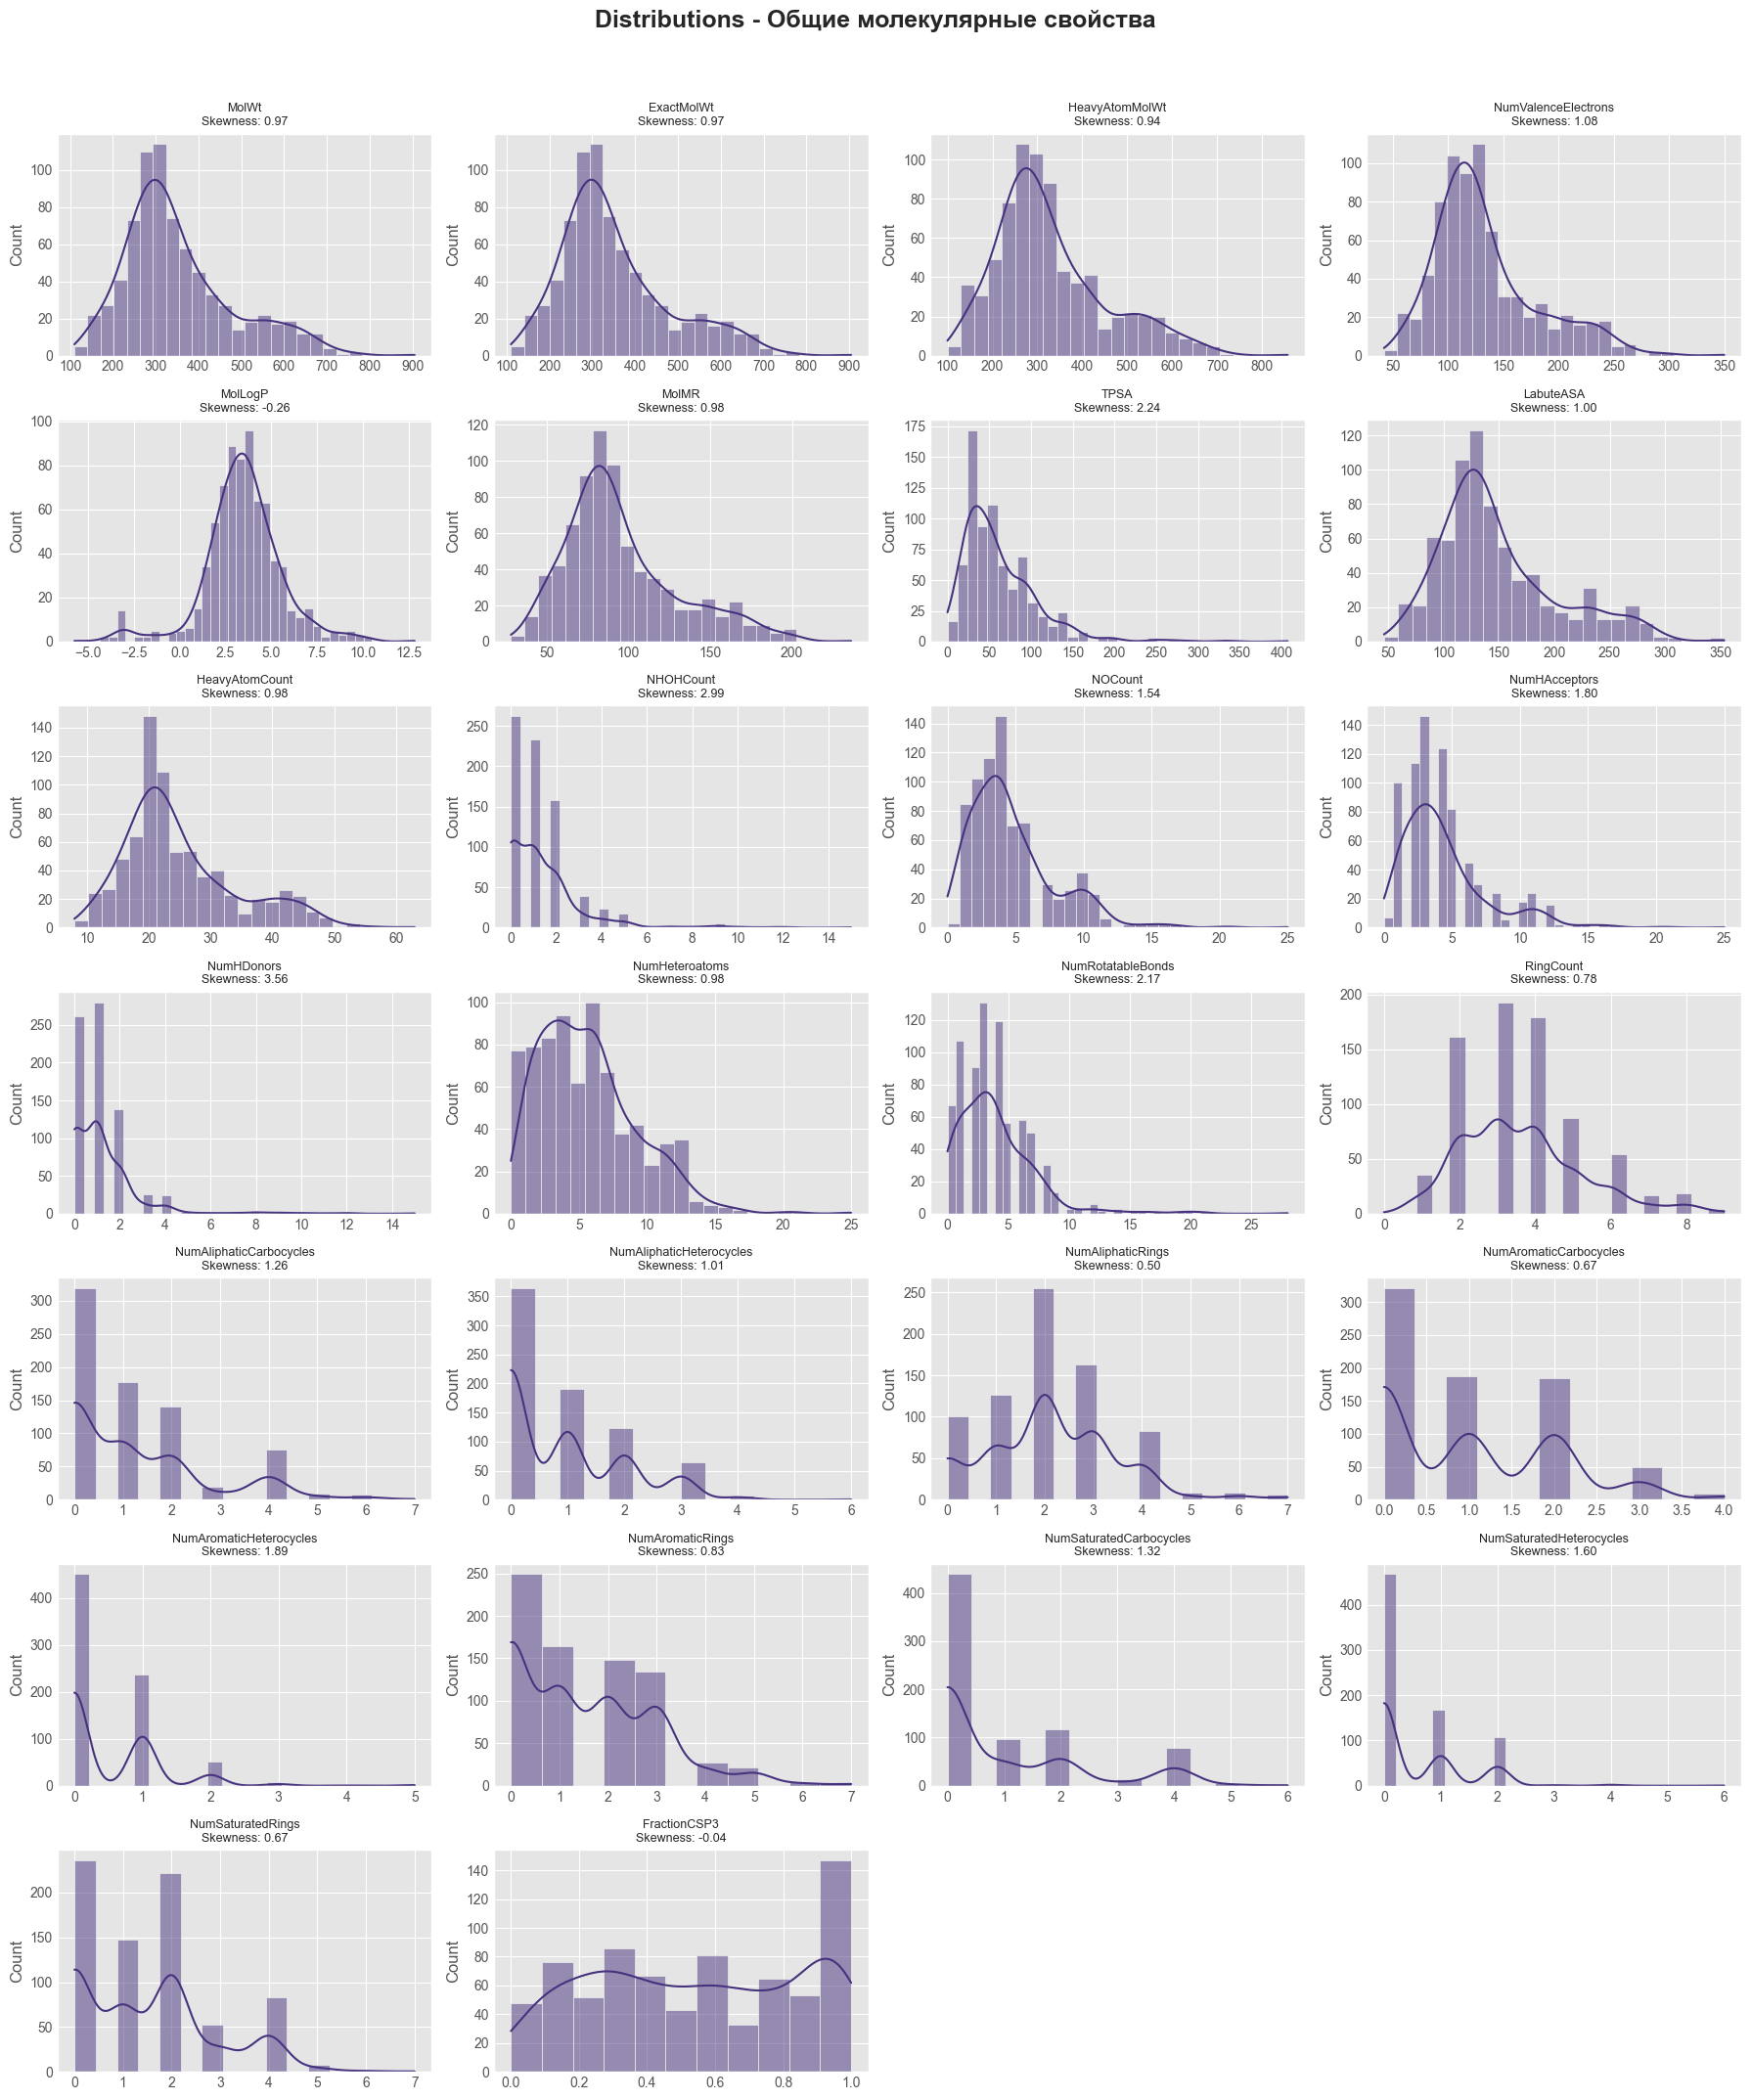

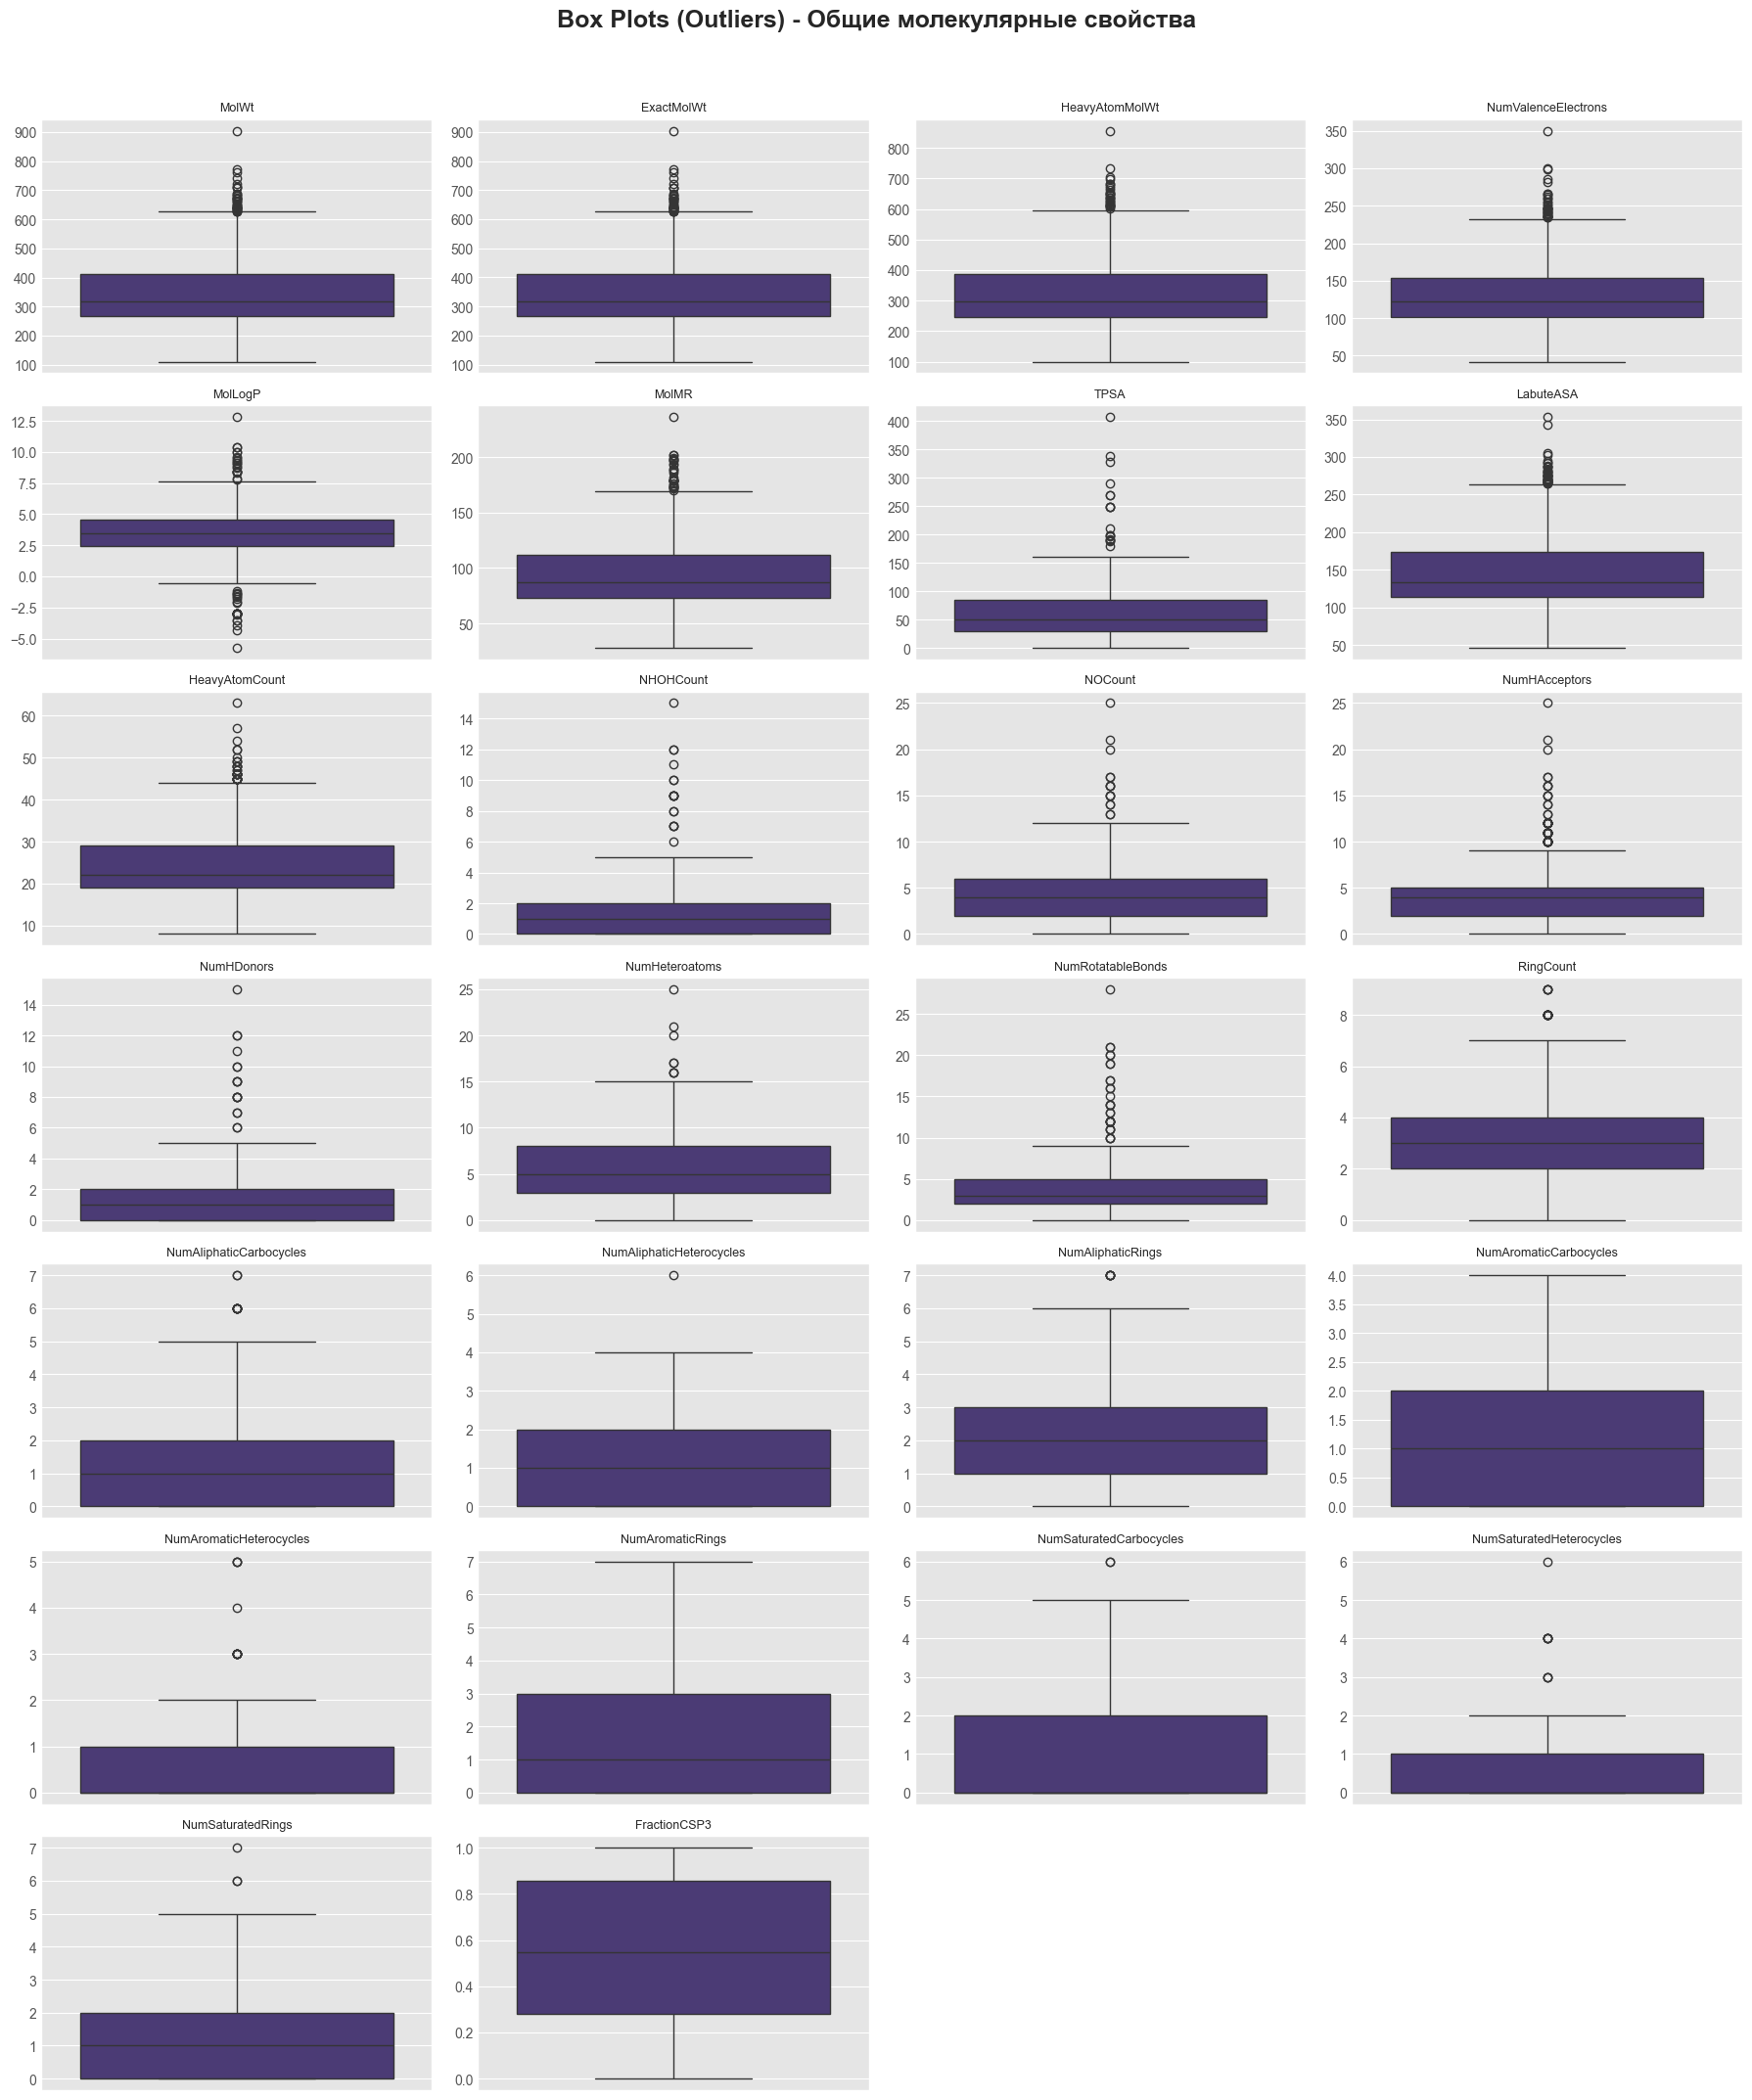

АНАЛИЗ ВЫБРОСОВ (метод IQR)


,feature,outliers_count,outliers_pct
11,NumHAcceptors,73,9.720373
4,MolLogP,49,6.524634
7,LabuteASA,39,5.193076
1,ExactMolWt,37,4.926764
3,NumValenceElectrons,36,4.793609
0,MolWt,36,4.793609
8,HeavyAtomCount,35,4.660453
5,MolMR,31,4.127830
14,NumRotatableBonds,29,3.861518
2,HeavyAtomMolWt,29,3.861518


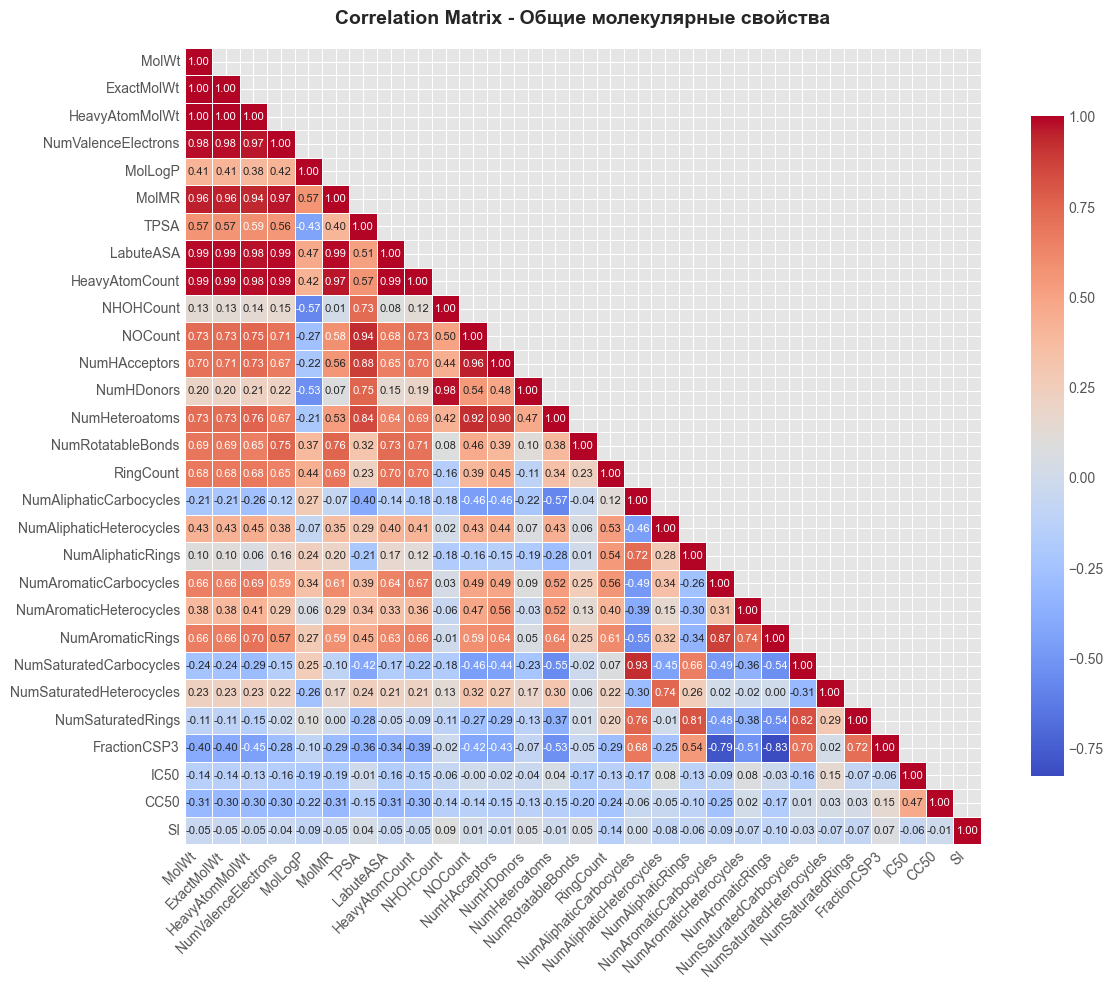

ПАРЫ ПРИЗНАКОВ С КОРРЕЛЯЦИЕЙ > 0.95


,feature1,feature2,correlation
0,MolWt,ExactMolWt,0.999999
1,MolWt,HeavyAtomMolWt,0.996985
6,ExactMolWt,HeavyAtomMolWt,0.996955
19,LabuteASA,HeavyAtomCount,0.994571
16,NumValenceElectrons,HeavyAtomCount,0.990679
15,NumValenceElectrons,LabuteASA,0.990416
10,ExactMolWt,HeavyAtomCount,0.989688
5,MolWt,HeavyAtomCount,0.989531
9,ExactMolWt,LabuteASA,0.988640
4,MolWt,LabuteASA,0.988563


In [251]:
# Распределения
plot_distributions(train, GENERAL_MOLECULAR_PROPERTIES, group_name=GENERAL_MOLECULAR_PROPERTIES_GORUP_NAME)

# Выбросы
plot_boxplots(train, GENERAL_MOLECULAR_PROPERTIES, group_name=GENERAL_MOLECULAR_PROPERTIES_GORUP_NAME)
print("АНАЛИЗ ВЫБРОСОВ (метод IQR)")
display(analyze_outliers(train, GENERAL_MOLECULAR_PROPERTIES))

# Корреляция
plot_correlation_heatmap(train, GENERAL_MOLECULAR_PROPERTIES, TARGETS, group_name=GENERAL_MOLECULAR_PROPERTIES_GORUP_NAME)
print("ПАРЫ ПРИЗНАКОВ С КОРРЕЛЯЦИЕЙ > 0.95")
display(find_highly_correlated_pairs(train, GENERAL_MOLECULAR_PROPERTIES))

`MolWt (молекулярная масса)`: распределение имеет умеренную правостороннюю асимметрию (skewness ≈ 0.97). Большинство молекул сосредоточено в диапазоне 200-450 Da, при этом наблюдается тяжелый хвост из молекул с массой более 600 Da. Выбросы составляют 4.79%. Для линейных моделей будет лучше применить лог-трансформацию, деревья устойчивы к такой асимметрии.

`ExactMolWt (точная молекулярная масса)`: распределение практически идентично MolWt (skewness ≈ 0.97), что ожидаемо из-за абсолютной корреляции между этими признаками. Выбросы составляют 4.93%. Признак является избыточным и его необходимо удалить.

`HeavyAtomMolWt (масса тяжелых атомов)`: признак абсолютно коррелирует с MolWt, выбросы составляют 3.86%, его необходимо удалить.

`NumValenceElectrons (количество валентных электронов)`: признак тесно связан с LabuteASA и HeavyAtomCount (экстремально высокая корреляция ≈ 0.99), выбросы составляют 4.79%, его необходимо удалить.

`MolLogP (липофильность)`: распределение близко к симметричному (skewness ≈ -0.26). Диапазон значений от -5.8 до 12.8, большинство значений находится в области 2-5. Выбросы составляют 6.52%. Трансформация для линейных моделей не требуется.

`MolMR (молярная рефракция)`: распределение имеет умеренную правостороннюю асимметрию (skewness ≈ 0.98). Большинство значений находится в диапазоне 70-120, редкие молекулы имеют MR > 180. Выбросы составляют 4.13%. Признак имеет лучшую корреляцию с таргетами по сравнению с MolWt, поэтому оставлен в модели. Для линейных моделей рекомендуется лог-трансформация, деревья устойчивы.

`TPSA (топологическая полярная поверхность)`: сильная правосторонняя асимметрия (skewness ≈ 2.24). Подавляющее большинство значений менее 100, присутствуют значения выше 300. Выбросы составляют 2.40%. Для линейных моделей необходима лог-трансформация.

`LabuteASA (приблизительная площадь поверхности)`: распределение отражает общий размер молекулы (экстремально высокая корреляция ≈ 0.99), выбросы составляют 5.19%. Признак необходимо удалить.

`HeavyAtomCount (количество тяжелых атомов)`: наблюдается экстремальная корреляция с MolWt ≈ 0.99, выбросы составляют 4.66%. Признак необходимо удалить.

`NHOHCount (количество групп NH и OH)`: сильная правосторонняя асимметрия (skewness ≈ 2.99). Большинство молекул имеют 0-2 такие группы, редкие молекулы содержат 5-15 доноров. Выбросы составляют 2.26%. Требуется лог-трансформация для линейных моделей.

`NOCount (суммарное количество атомов O и N)`: распределение идентично с распределением NumHAcceptors. Признак экстремально сильно коррелирует с NumHeteroatoms и NumHAcceptors ≈ 0.90, выбросы составляют 2.00%, его необходимо удалить.

`NumHAcceptors (акцепторы водородных связей)`: наблюдается экстремальная корреляция с NumHeteroatoms ≈ 0.90, выбросы составляют 9.72%, признак необходимо удалить.

`NumHDonors (доноры водородных связей)`: наблюдается экстремальная корреляция с NHOHCount ≈ 0.98, выбросы составляют 2.26%, признак необходимо удалить.

`NumHeteroatoms (количество гетероатомов)`: умеренная правосторонняя асимметрия (skewness ≈ 0.98). Большинство значений в диапазоне 3-8. Выбросы составляют 1.07%. Для линейных моделей рекомендуется лог-трансформация.

`NumRotatableBonds (количество вращаемых связей)`: сильная правосторонняя асимметрия (skewness ≈ 2.17). Большинство значений в диапазоне 2-5. Выбросы составляют 3.86%. Для линейных моделей необходима лог-трансформация.

`RingCount (общее количество колец)`: умеренная правосторонняя асимметрия (skewness ≈ 0.78). Большинство значений в диапазоне 2-4. Выбросы составляют 3.06%. Трансформация не обязательна.

`NumAliphaticCarbocycles (алифатические карбоциклы)`: выраженная правосторонняя асимметрия (skewness ≈ 1.26). Многие молекулы не содержат такие кольца (значение 0), большинство из тех, что содержат, имеют 1-2 кольца. Выбросы составляют 1.33%. Имеет очень сильную корреляционную связь с NumSaturatedCarbocycles ≈ 0.93. Для линейных моделей будет лучше применить лог-трансформацию.

`NumAliphaticHeterocycles (алифатические гетероциклы)`: выраженная правосторонняя асимметрия (skewness ≈ 1.01). Большинство молекул содержат 0-1 гетероцикл. Выбросы составляют 0.13%. Для линейных моделей будет лучше применить лог-трансформацию.

`NumAliphaticRings (общее количество алифатических колец)`: слабая правосторонняя асимметрия (skewness ≈ 0.50). Распределение почти симметрично, большинство молекул имеют 1-3 алифатических кольца. Выбросы составляют 0.80%. Возможно, что это сумма двух предыдущих признаков, необходимо проверить. Если так, то признак избыточен, и его нужно удалить.

`NumAromaticCarbocycles (ароматические карбоциклы)`: слабая правосторонняя асимметрия (skewness ≈ 0.67). Большинство значений в диапазоне 0-2. Выбросов нет. Трансформация не требуется.

`NumAromaticHeterocycles (ароматические гетероциклы)`: сильная правосторонняя асимметрия (skewness ≈ 1.89). Большинство значений 0 или 1. Выбросы составляют 1.60%. Для линейных моделей необходима лог-трансформация.

`NumAromaticRings (общее количество ароматических колец)`: умеренная правосторонняя асимметрия (skewness ≈ 0.83). Большинство молекул имеют 0-2 ароматических кольца. Выбросов нет. Возможно, что это сумма двух предыдущих признаков, необходимо проверить. Если так, то признак избыточен, и его нужно удалить.

`NumSaturatedCarbocycles (насыщенные карбоциклы)`: выраженная правосторонняя асимметрия (skewness ≈ 1.32). Многие молекулы имеют значение 0. Выбросы составляют 0.27%. Для линейных моделей рекомендуется лог-трансформация.

`NumSaturatedHeterocycles (насыщенные гетероциклы)`: сильная правосторонняя асимметрия (skewness ≈ 1.60). Большинство значений 0 или 1. Выбросы составляют 1.20%. Для линейных моделей необходима лог-трансформация.

`NumSaturatedRings (общее количество насыщенных колец)`: слабая правосторонняя асимметрия (skewness ≈ 0.67). Распределение почти симметрично, большинство молекул имеют 0-2 насыщенных кольца. Выбросы составляют 0.40%. Возможно, что это сумма двух предыдущих признаков, необходимо проверить. Если так, то признак избыточен, и его нужно удалить.

`FractionCSP3 (доля sp3-гибридизованных атомов углерода)`: распределение практически симметрично (skewness ≈ -0.04). Значения в основном лежат в диапазоне от 0.3 до 0.8. Выбросов нет. Трансформация не требуется.

Проверим, что `NumAliphaticRings` равен сумме двух других признаков `NumAliphaticCarbocycles` и `NumAliphaticHeterocycles`

In [252]:
check_sum = train['NumAliphaticCarbocycles'] + train['NumAliphaticHeterocycles']
is_equal = (train['NumAliphaticRings'] == check_sum).all()

print(f"NumAliphaticRings равен сумме NumAliphaticCarbocycles и NumAliphaticHeterocycles: {is_equal}")

NumAliphaticRings равен сумме NumAliphaticCarbocycles и NumAliphaticHeterocycles: True


Проверим, что `NumAliphaticRings` равен сумме двух других признаков `NumAromaticCarbocycles` и `NumAromaticHeterocycles`

In [253]:
check_sum = train['NumAromaticCarbocycles'] + train['NumAromaticHeterocycles']
is_equal = (train['NumAromaticRings'] == check_sum).all()

print(f"NumAromaticRings равен сумме NumAromaticCarbocycles и NumAromaticHeterocycles: {is_equal}")

NumAromaticRings равен сумме NumAromaticCarbocycles и NumAromaticHeterocycles: True


Проверим, что `NumAliphaticRings` равен сумме двух других признаков `NumSaturatedCarbocycles` и `NumSaturatedHeterocycles`

In [254]:
check_sum = train['NumSaturatedCarbocycles'] + train['NumSaturatedHeterocycles']
is_equal = (train['NumSaturatedRings'] == check_sum).all()

print(f"NumSaturatedRings равен сумме NumSaturatedCarbocycles и NumSaturatedHeterocycles: {is_equal}")

NumSaturatedRings равен сумме NumSaturatedCarbocycles и NumSaturatedHeterocycles: True


На основе проведенного EDA сформирован список признаков, подлежащих удалению.

### Удаляемые признаки (13)

| Причина удаления | Признаки |
|-----------------|----------|
| **Высокая корреляция с MolWt (дублирование)** | `ExactMolWt`, `HeavyAtomMolWt` |
| **Высокая корреляция с LabuteASA / HeavyAtomCount** | `NumValenceElectrons`, `LabuteASA`, `HeavyAtomCount` |
| **Дублирование донорно-акцепторных признаков, высокая корреляция с NumHeteroatoms** | `NHOHCount`, `NOCount`, `NumHAcceptors`, `NumHDonors` |
| **Избыточные суммы компонент** | `NumAliphaticRings`, `NumAromaticRings`, `NumSaturatedRings` |
| **Уступает по корреляции с таргетами** | `MolWt` (оставлен `MolMR`) |

In [255]:
GENERAL_MOLECULAR_PROPERTIES_TO_DROP = [
    'MolWt',
    'ExactMolWt',
    'HeavyAtomMolWt',
    'NumValenceElectrons',
    'LabuteASA',
    'HeavyAtomCount',
    'NHOHCount',
    'NOCount',
    'NumHAcceptors',
    'NumHDonors',
    'NumAliphaticRings',
    'NumAromaticRings',
    'NumSaturatedRings',
]

train = train.drop(columns=GENERAL_MOLECULAR_PROPERTIES_TO_DROP)
test = test.drop(columns=GENERAL_MOLECULAR_PROPERTIES_TO_DROP)
GENERAL_MOLECULAR_PROPERTIES = [f for f in GENERAL_MOLECULAR_PROPERTIES if f not in GENERAL_MOLECULAR_PROPERTIES_TO_DROP]

### Анализ дрифта распределений (train vs test)

In [256]:
drift_report = detect_drift(train, test, GENERAL_MOLECULAR_PROPERTIES)
display(drift_report[drift_report['drift'] == True])

,feature,ks_statistic,p_value,drift


Дрифт распределений между обучающей и тестовой выборками отсутствует. Все признаки имеют статистически схожие распределения в train и test (p-value ≥ 0.05).

### Корреляция признаков с целевыми переменными

In [257]:
print_top_correlations_with_targets(train, GENERAL_MOLECULAR_PROPERTIES, TARGETS)


Топ-5 корреляций с IC50:
  NumSaturatedHeterocycles: 0.1467 (слабая)
  NumAliphaticHeterocycles: 0.0806 (очень слабая)
  NumAromaticHeterocycles: 0.0801 (очень слабая)
  NumHeteroatoms: 0.0396 (очень слабая)
  TPSA: -0.0081 (очень слабая)

Топ-5 корреляций с CC50:
  FractionCSP3: 0.1501 (слабая)
  NumSaturatedHeterocycles: 0.0331 (очень слабая)
  NumAromaticHeterocycles: 0.0153 (очень слабая)
  NumSaturatedCarbocycles: 0.0075 (очень слабая)
  NumAliphaticHeterocycles: -0.0524 (очень слабая)

Топ-5 корреляций с SI:
  FractionCSP3: 0.0706 (очень слабая)
  NumRotatableBonds: 0.0546 (очень слабая)
  TPSA: 0.0399 (очень слабая)
  NumAliphaticCarbocycles: 0.0014 (очень слабая)
  NumHeteroatoms: -0.0109 (очень слабая)


### Выводы по группе "Общие молекулярные свойства"

#### Качество данных

| Показатель | Результат |
|------------|-----------|
| **Пропуски** | Отсутствуют во всех признаках (0%) |
| **Выбросы** | 3 признака имеют >5% выбросов: `NumHAcceptors` (9.7%), `MolLogP` (6.5%), `LabuteASA` (5.2%) |
| **Проблемные признаки** | 13 признаков удалены из-за высокой корреляции и дублирования |

#### Необходимые преобразования

| Преобразование | Признаки | Причина |
|----------------|----------|---------|
| **Лог-трансформация** | `MolMR`, `TPSA`, `NumHeteroatoms`, `NumRotatableBonds`, `NumAliphaticCarbocycles`, `NumAliphaticHeterocycles`, `NumAromaticHeterocycles`, `NumSaturatedCarbocycles`, `NumSaturatedHeterocycles` | Сильная асимметрия (skewness > 1) |
| **Масштабирование** | Все 13 оставленных признаков | Разные диапазоны значений (0-1 до 0-400) |
| **Импутация** | Не требуется | Пропуски отсутствуют |
| **Удаление признаков** | 13 признаков (список выше) | Высокая корреляция (>0.95) или дублирование |

#### Наиболее коррелирующие с таргетами признаки

| Таргет | Топ-5 признаков (корреляция) |
|--------|------------------------------|
| **IC50** | `NumSaturatedHeterocycles` (0.15), `NumAliphaticHeterocycles` (0.08), `NumAromaticHeterocycles` (0.08), `NumHeteroatoms` (0.04), `TPSA` (-0.01) |
| **CC50** | `FractionCSP3` (0.15), `NumSaturatedHeterocycles` (0.03), `NumAromaticHeterocycles` (0.02), `NumSaturatedCarbocycles` (0.01), `NumAliphaticHeterocycles` (-0.05) |
| **SI** | `FractionCSP3` (0.07), `NumRotatableBonds` (0.05), `TPSA` (0.04), `NumAliphaticCarbocycles` (0.00), `NumHeteroatoms` (-0.01) |